## Data Preparation

In [527]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [528]:
# 1
df = pd.read_csv("Algerian_forest_fires_dataset.csv")
print(df.shape)

(247, 14)


In [529]:
# 2
print(df.isnull().sum())
df = df.dropna()

day            1
month          2
year           2
Temperature    2
 RH            2
 Ws            2
Rain           2
FFMC           2
DMC            2
DC             2
ISI            2
BUI            2
FWI            2
Classes        3
dtype: int64


In [530]:
# 3
df["Date"] = df["day"] + "/" + df["month"] + "/" + df["year"]
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')
df = df.set_index('Date').sort_index()
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
Date,,,,,,,,,,,,,,
2012-06-01,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
2012-06-01,1,6,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire
2012-06-02,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2012-06-02,2,6,2012,30,73,13,4,55.7,2.7,7.8,0.6,2.9,0.2,not fire
2012-06-03,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire


In [531]:
# 4
df.columns = df.columns.str.strip()
print(df.columns)
df["Classes"] = df["Classes"].str.strip()
df["Classes"] = df["Classes"].astype("category")
print(df.info())


Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes'],
      dtype='str')
<class 'pandas.DataFrame'>
DatetimeIndex: 244 entries, 2012-06-01 to NaT
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   day          244 non-null    str     
 1   month        244 non-null    str     
 2   year         244 non-null    str     
 3   Temperature  244 non-null    str     
 4   RH           244 non-null    str     
 5   Ws           244 non-null    str     
 6   Rain         244 non-null    str     
 7   FFMC         244 non-null    str     
 8   DMC          244 non-null    str     
 9   DC           244 non-null    str     
 10  ISI          244 non-null    str     
 11  BUI          244 non-null    str     
 12  FWI          244 non-null    str     
 13  Classes      244 non-null    category
dtypes: category(1), str(13)
memory usage: 26.9 KB
None


## Data Analysis

In [532]:
# 1
df_filter = df[(df.index >= "2012-08-01") & (df.index <= '2012-08-15')]
print(df_filter)    

           day month  year Temperature  RH  Ws Rain  FFMC   DMC    DC   ISI  \
Date                                                                          
2012-08-01   1     8  2012          38  52  14    0  78.3   4.4  10.5     2   
2012-08-01   1     8  2012          36  45  14    0  78.8   4.8  10.2     2   
2012-08-02   2     8  2012          40  34  14    0  93.3  10.8  21.4  13.8   
2012-08-02   2     8  2012          35  55  12  0.4    78   5.8    10   1.7   
2012-08-03   3     8  2012          39  33  17    0  93.7  17.1  32.1  17.2   
2012-08-03   3     8  2012          35  63  14  0.3  76.6   5.7    10   1.7   
2012-08-04   4     8  2012          38  35  15    0  93.8    23  42.7  15.7   
2012-08-04   4     8  2012          34  69  13    0    85   8.2  19.8     4   
2012-08-05   5     8  2012          34  65  13    0  86.8  11.1  29.7   5.2   
2012-08-05   5     8  2012          34  42  17  0.1  88.3  23.6  52.5    19   
2012-08-06   6     8  2012          32  75  14    0 

In [533]:
# 2
df["Temperature"] = pd.to_numeric(df["Temperature"], errors='coerce')
avg_temp = df.filter(["month", "Temperature"]).groupby("month").mean()
print(avg_temp)
print(avg_temp.idxmax())

       Temperature
month             
6        30.800000
7        32.983607
8        35.338710
9        29.366667
month          NaN
Temperature    8
dtype: str


In [534]:
# 2
avg_max_fire_count = df[(df["month"] == '8') & (df["Classes"] == 'fire')].value_counts().sum()
print(avg_max_fire_count)

51


In [535]:
# 3
df["Ws"] = pd.to_numeric(df["Ws"], errors="coerce")
five_max_ws = df["Ws"].sort_values(ascending=False).head(5)
print(df.loc[five_max_ws.index, ["Temperature", "Ws"]])
print(df.nlargest(5, 'Ws')[['Temperature', 'Ws']])

            Temperature    Ws
Date                         
2012-09-28         27.0  29.0
2012-09-28         32.0  14.0
2012-09-14         28.0  15.0
2012-09-14         22.0  26.0
2012-06-03         26.0  22.0
2012-06-03         29.0  14.0
2012-07-23         31.0  17.0
2012-07-23         27.0  22.0
2012-06-11         31.0  21.0
2012-06-11         31.0  14.0
            Temperature    Ws
Date                         
2012-09-28         27.0  29.0
2012-09-14         22.0  26.0
2012-06-03         26.0  22.0
2012-07-23         27.0  22.0
2012-06-11         31.0  21.0


In [536]:
# 4
df["FWI"] = pd.to_numeric(df["FWI"], errors="coerce")
df[["FWI", "Classes"]].groupby("Classes").mean()

,FWI
Classes,
Classes,NaN
fire,11.732847
not fire,0.964151


In [537]:
# 5
max_count = -np.inf
count = 0

for row in df.itertuples():
    if row.Classes == "not fire":
        count += 1
        if count > max_count:
            max_count = count
    else:
        count = 0

print(f"ช่วงที่ไม่เกิดไฟป่าต่อเนื่องนานที่สุด {max_count} วัน")

ช่วงที่ไม่เกิดไฟป่าต่อเนื่องนานที่สุด 16 วัน


## Data Visualization

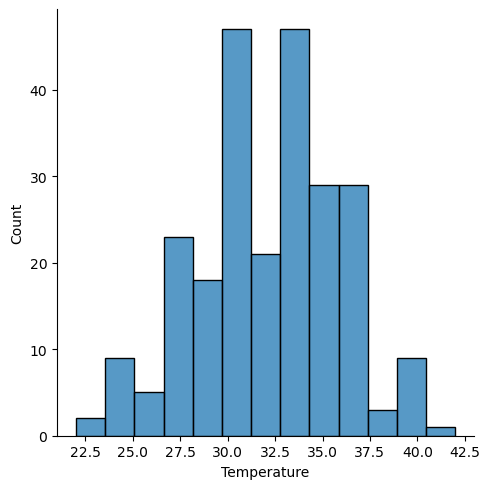

In [538]:
# 1 
sns.displot(data = df.Temperature)

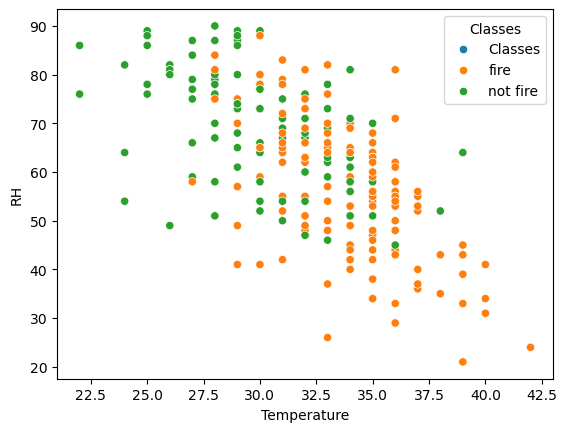

In [539]:
# 2
df["RH"] = pd.to_numeric(df["RH"], errors="coerce")
df_plot = df.dropna(subset=["Temperature", "RH", "Classes"])
sns.scatterplot(data=df_plot, x="Temperature", y="RH", hue="Classes")
plt.xlabel("Temperature")
plt.ylabel("RH")
plt.show()

<Axes: xlabel='month', ylabel='FFMC'>

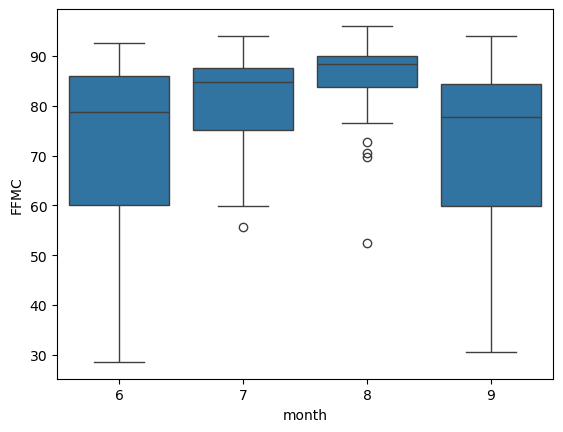

In [540]:
# 3
df["FFMC"] = pd.to_numeric(df["FFMC"], errors="coerce")
df_plot = df.dropna(subset=["FFMC", "month"])
sns.boxplot(data=df_plot, x="month", y="FFMC")

                    Rain
month Classes           
6     fire      0.040000
      not fire  1.642857
7     fire      0.250000
      not fire  0.795652
8     fire      0.049020
      not fire  2.300000
9     fire      0.008696
      not fire  1.921622
month Classes        NaN


<Axes: xlabel='Rain', ylabel='Classes'>

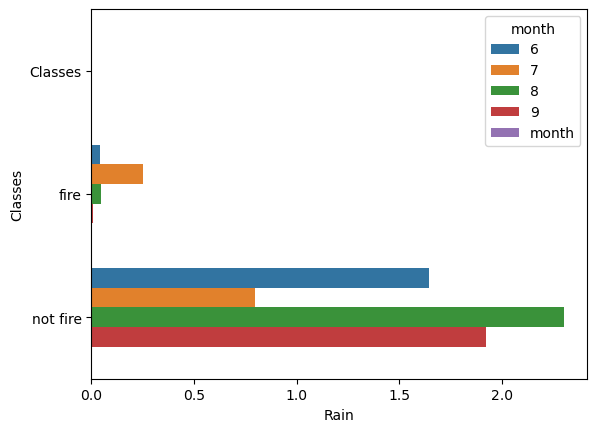

In [541]:
# 4
df["Rain"] = pd.to_numeric(df["Rain"], errors="coerce")
df_mean_rain = df.filter(["month", "Rain", "Classes"]).groupby(["month", "Classes"]).mean()
print(df_mean_rain)
sns.barplot(data=df_mean_rain.reset_index(), x="Rain", y="Classes", hue="month")

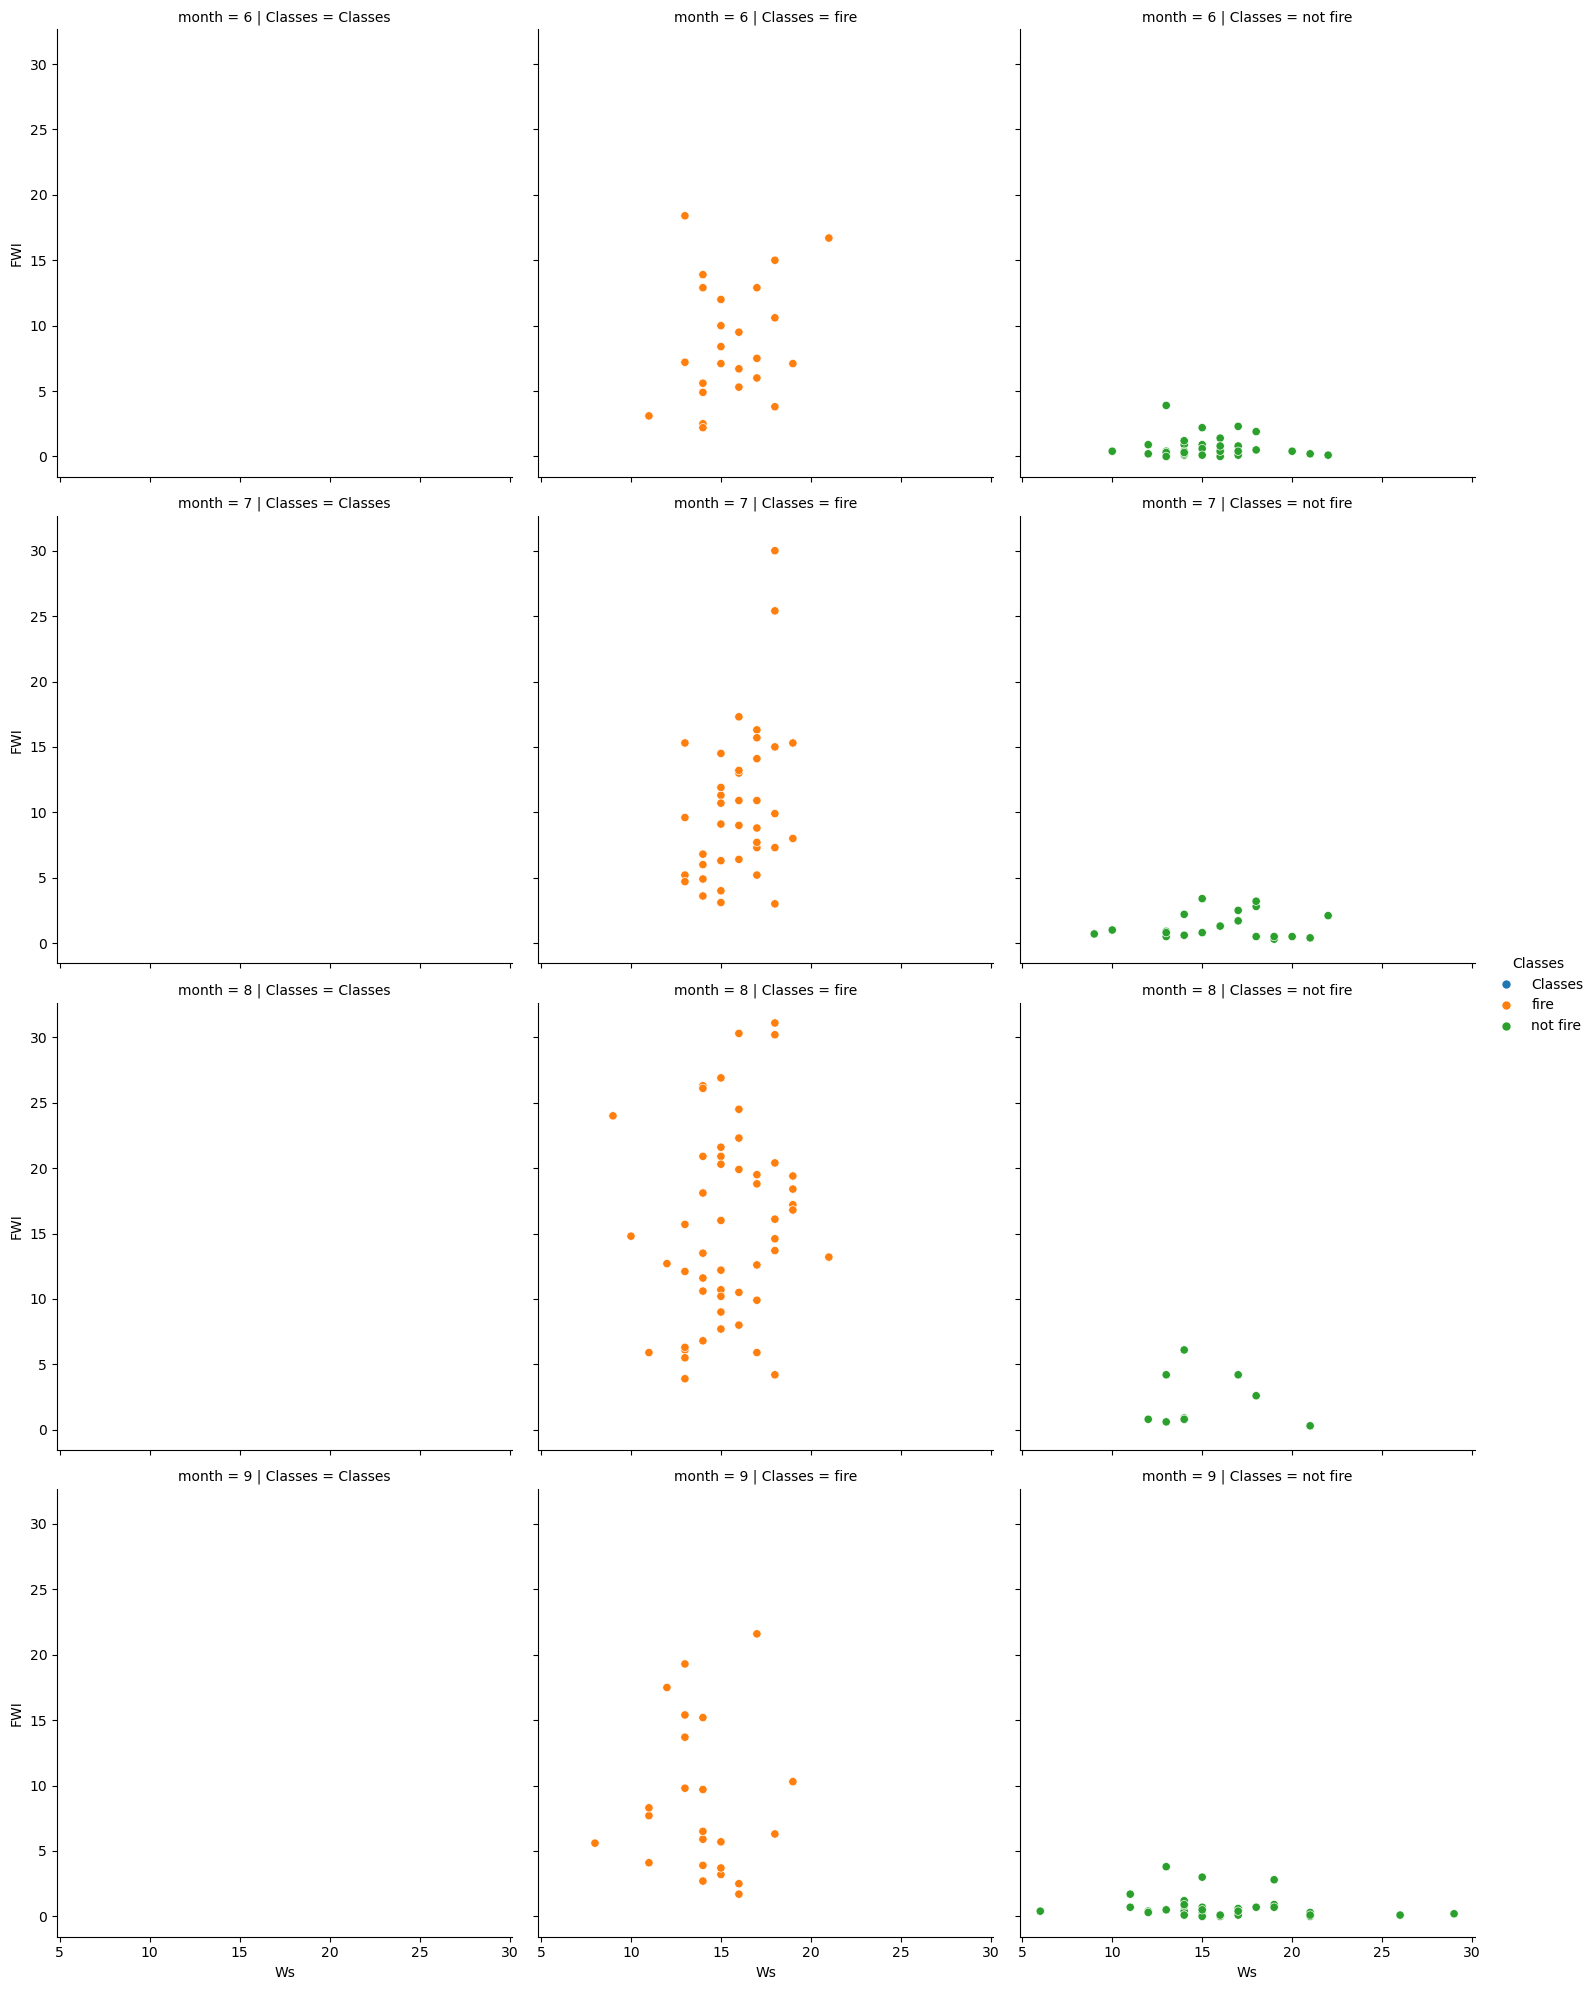

In [542]:
# 5
df["Ws"] = pd.to_numeric(df["Ws"], errors="coerce")
df_plot = df.dropna(subset=["Ws", "FWI"])
sns.relplot(data=df_plot, x="Ws", y="FWI", hue="Classes", row = "month", col="Classes",kind="scatter")